# Import and utils

In [1]:
%reload_ext autoreload
%autoreload 2

import os
import random
import itertools
import multiprocessing as mp
from collections import Counter
from collections import defaultdict

import numpy as np
import json
import pandas as pd
import math
import joblib
from tqdm import tqdm
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import clear_output
import statsmodels.api as sm
import scipy.stats

import xgi
import networkx as nx
from networkx.algorithms import bipartite

from generator import triadic_closure, polyadic_closure


# Growth models

## Erdos Renyi with fixed size distribution
For a given $p_{new}$ fraction of new nodes and $p_d$ an edge size distribution, this model generates a hypergraph where, each edge of a size $d$ (draw from $p_d$) is the union $n_{new}$ nodes (drawn from a binomial distribution with proba $p_{new}$ and $d$ trials) and $d - n_{new}$ previous nodes randomly choosen.

In [24]:
from generator import random_hypergraph
H = random_hypergraph(p_new = 0.5, M= 10, edge_size_dist='empirical')

/home/azaiez/Documents/These/Temporal_EC/.venv/lib/python3.12/site-packages/xgi/generators/random.py:152: UserWarning: This method is much slower than fast_random_hypergraph
  warn("This method is much slower than fast_random_hypergraph")
100%|██████████| 10/10 [00:00<00:00, 37052.16it/s]


## Preferential attachement Model

This model generates a growing hypergraph where each new edge mixes new and existing nodes.

- Start from a small random hypergraph.

- For each new edge, draw its size $d$ and the number of new nodes (via a binomial draw with probability $p_{new}$).

- The remaining $d-n_{new}$​ nodes are chosen preferentially from existing nodes, based on their current activity (degree).

- New edges reinforce existing nodes’ chances of being selected again.


In [ ]:
from generator import preferential_attachment

H = preferential_attachment(p_new = 0.5, ds = ds)


/home/azaiez/Documents/These/Temporal_EC/.venv/lib/python3.12/site-packages/xgi/generators/random.py:152: UserWarning: This method is much slower than fast_random_hypergraph
  warn("This method is much slower than fast_random_hypergraph")
100%|██████████| 10/10 [00:00<00:00, 19445.08it/s]


## Preferential with overlaps

This model generates a hypergraph with modular structure and overlapping participation patterns:

- Each new hyperedge has a size drawn from a specified distribution.
- A proportion $p_{new}$ of its nodes are new; the rest are sampled from existing nodes.
- Existing nodes are sampled with preferential attachment:
  - Nodes that already share a hyperedge with the current edge (`neighbors`) are sampled with weight proportional to `deg(i)^β_neigh`.
  - Other remaining nodes are sampled with weight proportional to `deg(i)^β_remaining`.
- The parameter `α ∈ [0, 1]` controls the trade-off between sampling from neighbors (`α`) and remaining nodes (`1 - α`).


In [26]:
from generator import random_overlaps_pref

M = 500 # Number of edges 
p_new = 0.7
alpha = 0.5
beta_neigh = 0.5
beta_remaining =0.5


random_overlaps_pref(M, alpha, beta_neigh, beta_remaining, p_new)

/home/azaiez/Documents/These/Temporal_EC/.venv/lib/python3.12/site-packages/xgi/generators/random.py:152: UserWarning: This method is much slower than fast_random_hypergraph
  warn("This method is much slower than fast_random_hypergraph")
100%|██████████| 500/500 [00:00<00:00, 4016.63it/s]


# Temporal models

## Temporal triadic closure
@The rise and fall of a networked society: A formal model 

In [ ]:
from generator import temporal_triadic_closure
M = 200
N = 100
eta = 0.5
l = 0
xi = 0

N = 100
M = 200
H = temporal_triadic_closure(N, M, eta, l, xi)


100%|██████████| 200/200 [00:00<00:00, 527.25it/s]


## Temporal polyadic closure

In [ ]:
from generator import temporal_polyadic_closure
M = 100
N= 100
mu = 100
p_r = 0.5
p_n=0.5
d = 10

temporal_polyadic_closure(N, M, mu, p_r, p_n, d )

N=100, M=100, μ=100.000, pr=0.500, pn=0.500, d=10: 100%|██████████| 100/100 [00:00<00:00, 964.04it/s]


# Triadic closure 
Biancini @Triadic closure as a basic generating mechanism of communities in complex networks \\
Jackson @Meeting Strangers and Friends of Friends: How Random Are Social Networks?

**Algorithm description**:
- Start with an empty graph with `m` nodes
- For each new node:
  - Connect to one existing node at random.
  - Repeat until `m` edges are added:
    - With probability `p`, attempt **triadic closure** by linking to a neighbor of the previous target (friend of a friend).
    - Otherwise, select a target uniformly at random.
- Repeat until `n` nodes are present.

**Model parameters**:
- `n`: total number of nodes.
- `m`: number of edges added per new node.
- `p`: probability of triadic closure vs. random attachment.
- `seed`: controls randomness for reproducibility.

In [31]:
from generator import triadic_closure
from metrics import local_clustering_coefficient
n0 = 4 # initial number of nodes
n = 3000
m = 3 # nb link node i attaches to
p = 0.9 # probability of friend of friend encounter

H = triadic_closure(n, m, p,seed = None)
clust = local_clustering_coefficient(H)
clust

np.float64(0.5389289803194367)

## Polyadic closure

This model generates a hypergraph through an iterative **polyadic closure** mechanism, where each new node connects to a group of `m−1` existing nodes, forming a hyperedge of size `m`.

**Model description**:
- Start with an empty hypergraph with `m` nodes
- New nodes are added one by one.
- Each new node forms a hyperedge of size `m`:
  - Initially connects to one existing node.
  - Then, with probability `p`, it attempts **polyadic closure** by choosing a neighbor of the last target (a "friend of a friend") not already in the hyperedge.
  - Otherwise, it selects a node at random.
  - This continues until the hyperedge reaches size `m`.

**Model parameters**:
- `n`: total number of nodes.
- `m`: size of each new hyperedge.
- `p`: probability of polyadic closure (vs. random encounter).
- `seed`: random seed for reproducibility.



In [45]:
from generator import m_polyadic_closure
n = 3000
m = 8
p = 0.9
n0 = m
seed = None
H= m_polyadic_closure(n, m, p, seed = seed)
clust = local_clustering_coefficient(H)
clust

np.float64(0.3465666008825484)

In [4]:
import numpy as np
from generator import polyadic_closure
M = [3, 5, 1]
n = 50
p = 0.5
seed= 2


# Load Data

In [2]:
model = 'polyadic_closure'
multiedges = False
df_metrics_all = pd.read_json(f'../out/metrics/{model}_metrics_multiedges_{multiedges}.json')

In [222]:
df_metrics =df_metrics_all.copy()
# Select simulations with and with p>1
#df_metrics= df_metrics[df_metrics['p'] >0.9]
# convert M column to dict
df_metrics['M'] = df_metrics['M'].apply(lambda x : {int(d): x[d] for d in x.keys()})
# Compute average edge size per node
df_metrics['avg_size'] = df_metrics['M'].apply(lambda M: sum(md*d for d, md in M.items())/sum(md for md in M.values()))
y_bins = np.linspace(df_metrics['avg_size'].min(), df_metrics['avg_size'].max(), 15)
df_metrics['avg_size_bin'] = pd.cut(df_metrics['avg_size'], bins=y_bins, include_lowest=True)
# Compute pairwise_size
df_metrics['pairwise_size'] = df_metrics['M'].apply(lambda M: sum([md * math.comb(d, 2) for d , md in M.items()]))


In [76]:
df_metrics[df_metrics['pairwise_size']==7]['M'].apply(str).drop_duplicates()

8      {2: 4, 3: 1}
44     {2: 1, 4: 1}
188    {2: 1, 3: 2}
291          {2: 7}
Name: M, dtype: object

# Analysis

## Aggregated statistics

In [223]:
from utils import plot_map_heatmap
label_map={
    'p': '$p$',
    'avg_size_bin' : r'$\overline{d}$',
    'pairwise_size' : r'$s_2$',
    'nb_clusters': 'number of clusters',
}
x = 'p'
y = 'pairwise_size'
col = None
row = None

col_wrap = 2

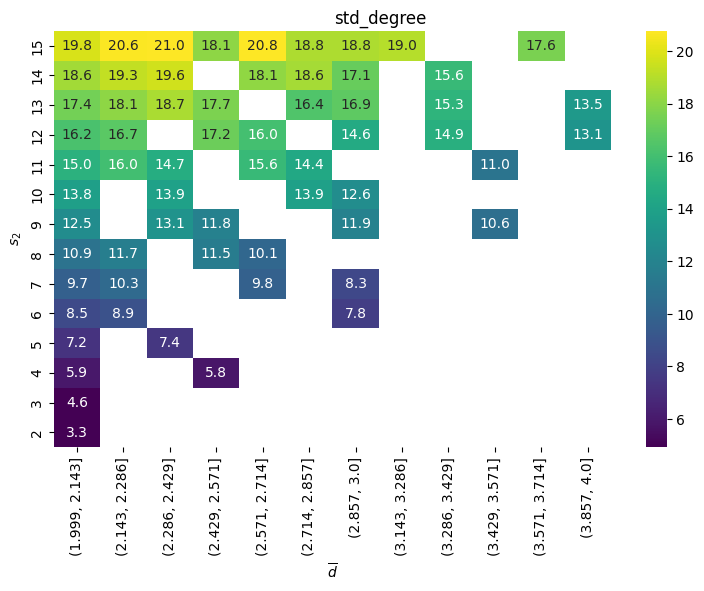

In [218]:
feature = 'std_degree'
plot_map_heatmap(df_metrics, feature, x, y, row, col, scale = 'quantile', col_wrap = col_wrap, agg_func = 'mean')
plt.suptitle(f'{label_map.get(feature, feature)}', y=0.83)
plt.xlabel(label_map.get(x,x))
plt.ylabel(label_map.get(y,y))
plt.savefig(f'../out/Figures/{feature}_{x}_{y}.pdf')

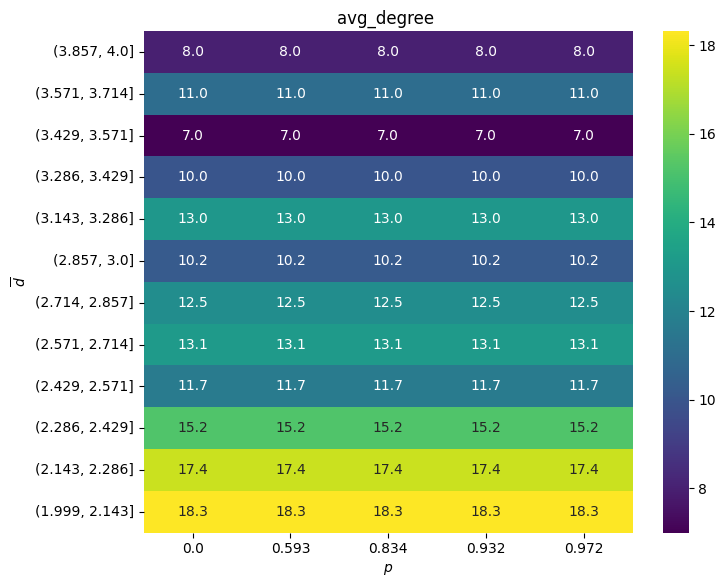

In [193]:
feature = 'avg_degree'
plot_map_heatmap(df_metrics, feature, x, y, row, col, scale = 'quantile', col_wrap = col_wrap, agg_func = 'mean')
plt.suptitle(f'{label_map.get(feature, feature)}', y=0.83)
plt.xlabel(label_map.get(x,x))
plt.ylabel(label_map.get(y,y))
plt.savefig(f'../out/Figures/{feature}_{x}_{y}.pdf')

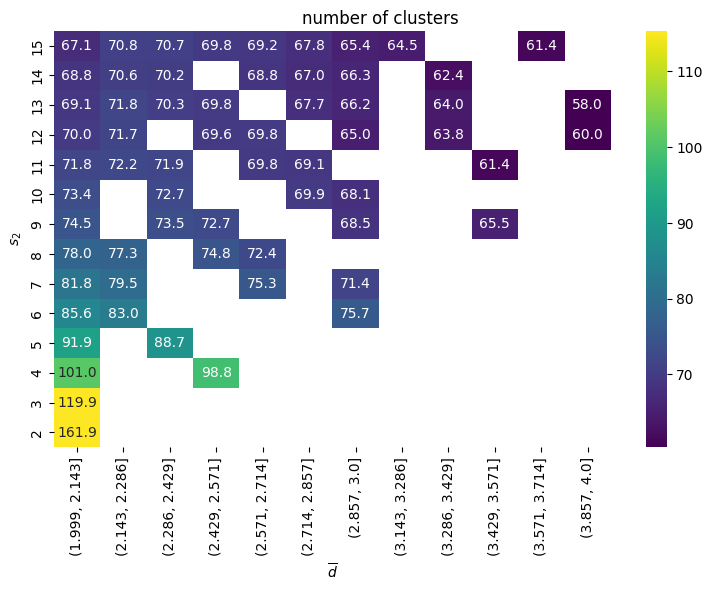

In [213]:
feature = 'nb_clusters'
plot_map_heatmap(df_metrics, feature, x, y, row, col, scale = 'quantile', col_wrap = col_wrap, agg_func = 'mean')
plt.suptitle(f'{label_map.get(feature, feature)}', y=0.83)
plt.xlabel(label_map.get(x,x))
plt.ylabel(label_map.get(y,y))
plt.savefig(f'../out/Figures/{feature}_{x}_{y}.pdf')


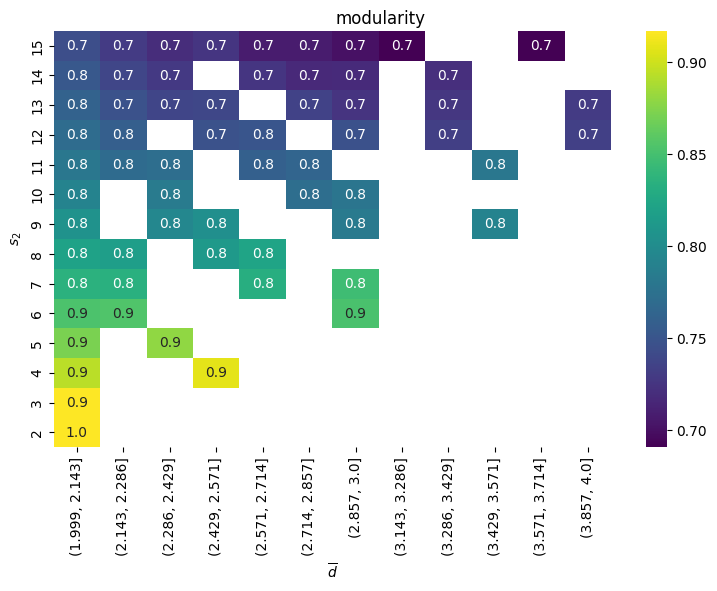

In [214]:
feature = 'modularity'
plot_map_heatmap(df_metrics, feature, x, y, row, col, scale = 'quantile', col_wrap = col_wrap, agg_func = 'mean')
plt.suptitle(f'{label_map.get(feature, feature)}', y=0.83)
plt.xlabel(label_map.get(x,x))
plt.ylabel(label_map.get(y,y))
plt.savefig(f'../out/Figures/{feature}_{x}_{y}.pdf')



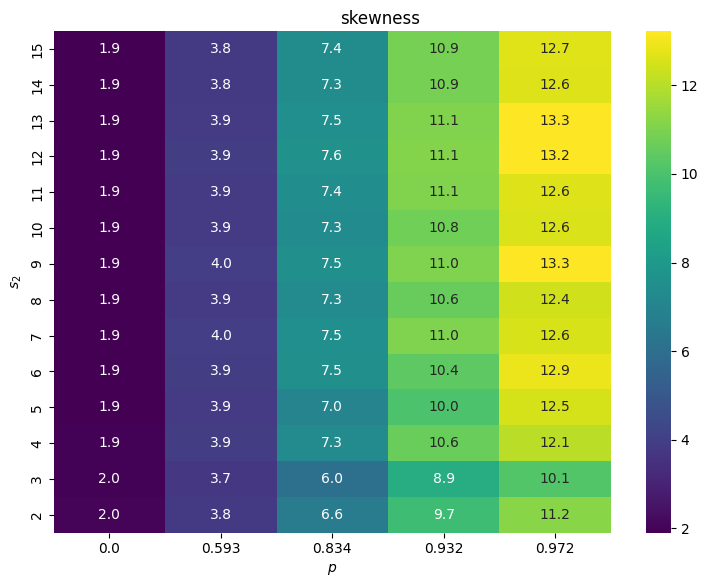

In [225]:
feature = 'skewness'
plot_map_heatmap(df_metrics, feature, x, y, row, col, scale = 'quantile', col_wrap = col_wrap, agg_func = 'mean')
plt.suptitle(f'{label_map.get(feature, feature)}', y=0.83)
plt.xlabel(label_map.get(x,x))
plt.ylabel(label_map.get(y,y))
plt.savefig(f'../out/Figures/{feature}_{x}_{y}.pdf')


In [135]:
df_metrics['skewness']

0         4.018305
1         1.939682
2         8.282472
3         9.903761
4         3.449242
           ...    
20495     3.840645
20496     4.078470
20497     1.960498
20498    13.372000
20499     3.637184
Name: skewness, Length: 20500, dtype: float64

## Rich club

In [238]:
import numpy as np
import pandas as pd
import networkx as nx
import xgi



n = 10_000

n0 =  20
p = 0.97
k0 = 1

Q = 30

Ms = [
    {2:7},
    {2:4,3:1},
    {2:1,3:2},
    {2:1,4:1}
]

metrics_path = f'../out/metrics/rc_n_{n}_p_{p}_n0_{n0}_k0_{k0}_Q_{Q}.json'
result = pd.read_json(metrics_path)



# Ensure M's keys are ints, and build a stable key for grouping/joins
result['M'] = result['M'].apply(lambda d: {int(k): v for k, v in d.items()})
result['M_key'] = result['M'].apply(lambda d: tuple(sorted(d.items())))


def explode_rc(df, col):
    tmp = df[['M_key','seed_M',col]].copy()
    tmp = tmp.assign(items=tmp[col].apply(lambda d: list(d.items()))).explode('items', ignore_index=True)
    tmp[['k', col]] = pd.DataFrame(tmp.pop('items').tolist(), columns=['k', col])
    tmp['k'] = tmp['k'].astype(int)
    tmp[col] = tmp[col].astype(float)
    return tmp

sur = explode_rc(result, 'rc')     # surrogates R
emp = explode_rc(result, 'rc_emp')   # empirical G (once per task; values will repeat across seed_swap)


# mean surrogate per (M_key, seed_M, k)
sur_mean = (sur
    .groupby(['M_key','seed_M','k'], as_index=False)['rc']
    .mean()
    .rename(columns={'rc':'rc_sur_mean'})
)

# empirical per (M_key, seed_M, k): take first occurrence
emp_first = (emp
    .drop_duplicates(['M_key','seed_M','k'])
    .rename(columns={'rc_g':'rc_emp'})
)

rc_df = sur_mean.merge(emp_first, on=['M_key','seed_M','k'], how='inner')
rc_df['rc_norm'] = rc_df['rc_emp'] / rc_df['rc_sur_mean']


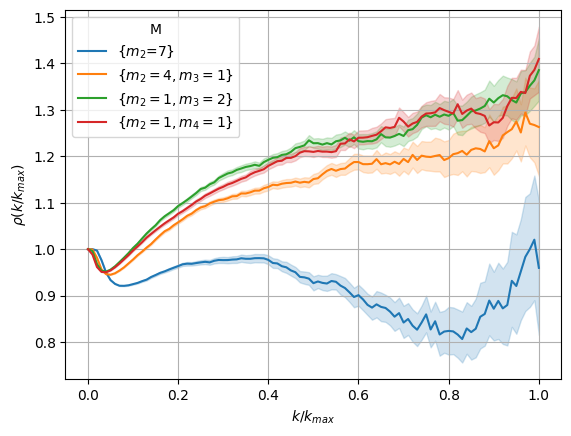

In [244]:

%matplotlib inline

label_map = {
    ((2, 7),): "{$m_2$=7}",
    ((2, 4), (3, 1)): "{$m_2=4,m_3=1$}",
    ((2, 1), (3, 2)): "{$m_2=1,m_3=2$}",
    ((2, 1), (4, 1)): "{$m_2=1,m_4=1$}",
}

def normalize_key(key):
    # e.g. [(2,7)] -> ((2,7),), [[2,7]] -> ((2,7),) etc.
    if isinstance(key, (list, tuple)):
        return tuple(tuple(x) if isinstance(x, (list, tuple)) else x for x in key)
    return key

rc_df['M_key_norm'] = rc_df['M_key'].apply(normalize_key)

# 3) Map safely (no reindexing), falling back to the original key as string if missing
rc_df['M_label'] = rc_df['M_key_norm'].apply(lambda k: label_map[k])

order_keys = [((2, 7),), ((2, 4), (3, 1)), ((2, 1), (3, 2)), ((2, 1), (4, 1))]
order_labels = [label_map[k] for k in order_keys]

rc_df['k'] = rc_df['k'] / rc_df.groupby(['M_label', 'seed_M'])['k'].transform('max')
rc_df['k'] = rc_df['k'].round(2)

ax = sns.lineplot(
    rc_df, x='k', y='rc_norm',
    hue='M_label', hue_order=order_labels,
    errorbar='ci'
)
ax.set_xlabel(r'$k/k_{max}$')
ax.set_ylabel(r'$\rho(k/k_{max})$')
ax.legend(title='M')



plt.grid()
plt.savefig(f'../out/Figures/rich_club.pdf')

## Edge intersection profile

In [ ]:
from configuration_model import vertex_labeled_MH

def edge_intersection_profile(H):
    intersection_count = defaultdict(lambda: defaultdict(int))
    intersection_sum = defaultdict(lambda: defaultdict(int))

    edges = H.edges.members()
    total_combinations = len(edges) * (len(edges) - 1) // 2
    for e1, e2 in tqdm(itertools.combinations(edges, 2), total=total_combinations, desc="Computing intersections"):
        k, l = len(e1) , len(e2)
        inter_size = len(set(e1) & set(e2))

        intersection_sum[k][l] += inter_size
        intersection_count[k][l] += 1
    return intersection_sum, intersection_count

def r_kl(H):
    # Compute dictonaries of conditional intersection profile 
    intersection_sum, intersection_count = edge_intersection_profile(H)
    # Create matrix
    sizes = range(2,max(list(intersection_count)) +1)
    R = np.zeros((len(sizes), len(sizes)))
    # Symetrize
    for i, k in enumerate(sizes):
        for j, l in enumerate(sizes):
            if intersection_count[k][l] or intersection_count[l][k]:
                R[i,j] = (intersection_sum[k][l] +intersection_sum[l][k] ) / (intersection_count[k][l] +intersection_count[l][k] )
            else :
                R[i,j] = np.nan
    return R

# Configuration model
def r_kl_null(H):
    X = xgi.Hypergraph(vertex_labeled_MH(H.edges.members(), n_steps = 100))
    return r_kl(X)

def normalize_r_kl(R_obs: np.array, R_null: list):
    '''
    R_obs = conditional intersection profile matrix
    R_null = list(conditional intersection profile matrix) results of simulation with null models
    '''

    R_mean = np.mean(np.stack(R_null), where= ~np.isnan(R_null),  axis = 0)
    return R_obs/R_mean

def pad_R_matrix(R, target_shape):
    """Pad the R matrix with NaNs to match the target shape."""
    padded = np.full(target_shape, np.nan)
    r_h, r_w = R.shape
    padded[:r_h, :r_w] = R
    return padded


In [13]:
from configuration_model import vertex_labeled_MH
H = xgi.Hypergraph(joblib.load('./out/edges_emp.joblib'))
H.cleanup()
r_kl_null(H)

mode=full │ multi=True │ sim=None |████████████████████| 3000/3000 [00:05<00:00, 559.75it/s]


3000 epochs completed, 1000 steps taken, 14 steps rejected.


Computing intersections:   4%|▎         | 16106634/433165461 [00:06<02:37, 2646719.67it/s]


KeyboardInterrupt: 

In [ ]:

# Empirical Hypergraph
nb_edges = 10000
max_size = 10
nb_itt = 20

H = xgi.Hypergraph(joblib.load('./out/edges_emp.joblib'))
H.cleanup()
# Reduce H to edges of size at most max_size
H = xgi.subhypergraph(H, edges = H.edges.filterby('size', max_size, 'lt'))
H = xgi.Hypergraph( H.edges.members()[: nb_edges])
args =[ H for _ in range (nb_itt)]

pool = mp.Pool()
results = pool.map(r_kl_null, args)
pool.close()

R_emp = r_kl(H)


In [15]:
# Set a common size range
sizes = range(2, max_size + 1)
shape = (len(sizes), len(sizes))

# Pad all null matrices to the same shape
R_null_padded = [pad_R_matrix(R, shape) for R in results]

<Axes: xlabel='x', ylabel='l'>

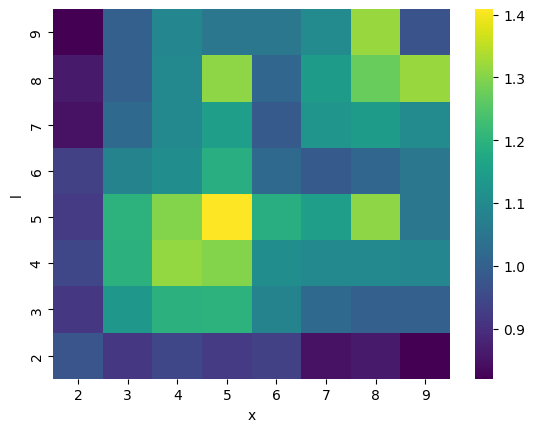

In [18]:
def normalize_r_kl(R_obs: np.array, R_null: list):
    '''
    R_obs = conditional intersection profile matrix
    R_null = list(conditional intersection profile matrix) results of simulation with null models
    '''

    R_mean = np.mean(np.stack(R_null), where= ~np.isnan(R_null),  axis = 0)
    return R_obs/R_mean

def heatmap_intersec_profile(R, **kwargs):
    ax = sns.heatmap(R,
                cmap="viridis", annot=False, fmt=".2f", **kwargs)
    ax.invert_yaxis()
    ax.set_ylabel('l')
    ax.set_xlabel('x')
    return ax

sizes = range(2,max(list(H.size().values()))+1)

kwargs = {
    'xticklabels': sizes,
    'yticklabels': sizes,
}
R_emp_norm = normalize_r_kl(R_emp, results)
heatmap_intersec_profile(R_emp_norm, **kwargs)

In [17]:

R_stack = np.stack(results)
R_std = np.std(R_stack, axis=0)
R_zscore = (R_emp - R_conf) / (R_std + 1e-6)
ax = sns.heatmap(R_zscore[: max_size, :max_size], cmap='coolwarm', center=0, **kwargs)
ax.invert_yaxis()


NameError: name 'R_conf' is not defined

In [19]:
# Growth model
H = xgi.Hypergraph(joblib.load('./out/edges_pref.joblib'))
#inter_sum_model , inter_count_model =  edge_intersetion_profile(H, max_edges) 
#R_mod = r_kl(inter_sum_model, inter_count_model)
R_mod_norm = normalize_r_kl(R_mod, results)
# Set min and max values for colorbar
vmin = min(np.min(R_emp, where = ~np.isnan(R_emp), initial = 0 ), np.min(R_mod, where = ~np.isnan(R_mod), initial = 0 ))
vmax = max(np.max(R_emp, where = ~np.isnan(R_emp), initial = 0 ), np.max(R_mod, where = ~np.isnan(R_mod), initial = 0 ))
# Plot heatmap
fig, ax = plt.subplots(1,2, figsize = (10,5))

R_conf = np.mean(np.array(results), axis = 0)
sizes = range(2,max(list(H.size().values()))+1)
max_size = 15

sizes = range(2,max_size+1)

kwargs = {
    'xticklabels': sizes,
    'yticklabels': sizes,
    'vmin': vmin,
    'vmax': vmax

}
heatmap_intersec_profile(R_emp_norm[:max_size-1, :max_size-1], **kwargs, **{'ax': ax[0]})
ax[0].set_title('Empirical')


heatmap_intersec_profile(R_mod_norm[:max_size-1, :max_size-1], **kwargs, **{'ax': ax[1]})
ax[1].set_title('Model') 

plt.tight_layout()

NameError: name 'R_mod' is not defined

Computing intersections: 100%|██████████| 449985000/449985000 [02:59<00:00, 2509287.75it/s]


<Axes: title={'center': 'r_kl'}, xlabel='l', ylabel='k'>

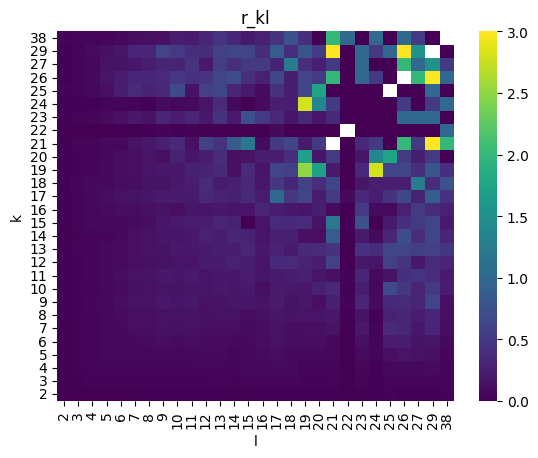

In [26]:
H = xgi.Hypergraph(joblib.load('./out/edges_pref.joblib'))
max_edges= 30000
inter_sum_pref , inter_count_pref =  edge_intersetion_profile(H, max_edges)
heatmap_intersec_profile(inter_sum_pref, inter_count_pref)

# Graph vizualisation

In [120]:
from generator import triadic_closure, polyadic_closure
from process_data import clean_edges
from utils import get_param_from_emp

# Load empirical hypegraph
edges_emp = joblib.load('../data/edges_ec.joblib')
H_emp = xgi.Hypergraph(edges_emp)
# Get paramaters from emprical hypergraph
edges = clean_edges(edges_emp)
D, P_new = get_param_from_emp(edges_emp)

p = 0.99
k0 = 1
n0 = None
seed = 1

H = polyadic_closure(
    D = D,
    p = p,
    P_new = P_new,
    k0 = k0,
    n0 = n0,
    seed = seed)

In [ ]:
from generator import polyadic_closure_2
import itertools
n = 2_000

n0 =  20
p = 0.97
k0 = 1
seed = 10



In [120]:
M = {2:2}
H1 = polyadic_closure_2(
    n=n,
    M=M,
    p=p, 
    k0 = k0,
    n0 = n0,
    seed = seed)

In [129]:
M = {2:7}
H1 = polyadic_closure_2(
    n=n,
    M=M,
    p=p, 
    k0 = k0,
    n0 = n0,
    seed = seed)


In [126]:

M = {2: 1, 3: 2}
H2 = polyadic_closure_2(
    n=n,
    M=M,
    p=p, 
    n0 = n0,
    seed = seed)



In [98]:
from utils import XGI_2_nxBipartite
import networkx as nx

H = H_f.copy()
#H.cleanup(relabel = False, multiedges = True)
B = XGI_2_nxBipartite(H)
edges= H.edges.members()
step = 1
nodes_seen = set()
all_future_nodes = [set(edge) for edge in edges]
    
# for t, edge in enumerate(tqdm(H.edges)):
#     start_time = t * step
#     end_time = start_time + step
    
#     # Assign times to hyperedge node
#     B.nodes[edge]['start'] = start_time
#     # B.nodes[edge]['end'] = end_time

#     current_nodes = set(edges[t])
#     new_nodes = current_nodes - nodes_seen

#     # Dead nodes = previously seen nodes that do not appear in any future edges
#     future_nodes = set().union(*all_future_nodes[t+1:])
#     dead_nodes = nodes_seen - future_nodes

#     # Assign timestamps
#     for node in new_nodes:
#         B.nodes[node]['start'] = start_time
#     # for node in dead_nodes:
#     #     if 'end' not in B.nodes[node]:  # Avoid overwriting if already set
#     #         B.nodes[node]['end'] = start_time
#     nodes_seen.update(current_nodes)

nx.write_gexf(B, "../out/graph_viz/H.gexf")

## Temporal dynamics

In [180]:
import itertools  
from generator import polyadic_closure, preferential_attachment, random_hypergraph
from metrics import gini, evolution_nb_nodes, degrees_t
from utils import get_param_from_emp, calibrate_from_emp, rescale_pnew, clean_edges

dataset = 'village'
# Load empirical hypegraph
edges_emp = joblib.load(f'../data/edges_{dataset}.joblib')
np.random.shuffle(edges_emp)
edges_emp = clean_edges(edges_emp)
H_emp = xgi.Hypergraph(edges_emp)
# Get paramaters from emprical hypergraph
seed = 1
n0 = max(H_emp.size().values())
k0 = 1

D, P_new, t0 =  calibrate_from_emp(edges_emp, n0, shuffle = False, seed = seed)

# Generate polyadic closure model
p = 0.99


H_f = polyadic_closure(
    D = D,
    p = p,
    P_new = P_new,
    redirection = False,
    k0 = k0,
    n0 = n0,
    seed = seed
    )


In [182]:
    


# # Generate preferential attachement
if dataset == 'village':
    
    H_p = preferential_attachment(
        D = D,
        P_new = P_new,
        k0 = k0,
        n0 = n0,
        seed = seed
        )
else:
    H_p = joblib.load(f'../out/simulations/preferential/H_p_{dataset}.joblib')
    

# Generate random hypergraph
H_r = random_hypergraph(
    D = D,
    P_new = P_new,
    k0 = k0,
    n0 = n0,
    seed = seed
)


100%|██████████| 4373/4373 [00:05<00:00, 852.05it/s] 


In [184]:
from metrics import clustering_metrics
results = [{'model': model, 'H': H} for model, H in zip(['empirical', 'FoF','PA', 'random'],[H_emp, H_f, H_p, H_r])]
for result in results:
    label = result['model']
    H = result['H']
    edges = H.edges.members().copy()
    H_relabeled = xgi.Hypergraph()
    for e in edges:
        H_relabeled.add_edge(e, idx = f'e_{H_relabeled.num_edges}')
    print(label, clustering_metrics(H_relabeled))

empirical {'modularity': np.float64(0.7917857633306191), 'nb_clusters': np.int64(13)}
FoF {'modularity': np.float64(0.49958089942700024), 'nb_clusters': np.int64(8)}
PA {'modularity': np.float64(0.2674045565306503), 'nb_clusters': np.int64(26)}
random {'modularity': np.float64(0.28073428445452253), 'nb_clusters': np.int64(24)}


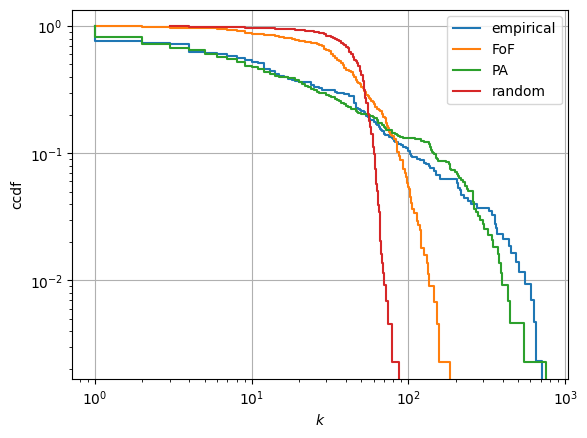

In [185]:
for result in results:
    label = result['model']
    H = result['H']
    deg_dict = H.degree()                 # dict-like: {node: degree}
    deg = np.array(list(deg_dict.values()), dtype=float) 
    vals = np.sort(deg)
    y = 1.0 - np.arange(1, vals.size + 1) / vals.size
    plt.step(vals, y, where='post', label=label)
    plt.loglog()
plt.ylabel('ccdf')
plt.xlabel('$k$')
plt.grid()
plt.legend()
plt.savefig(f'../out/Figures/degree_dist_{dataset}.pdf')


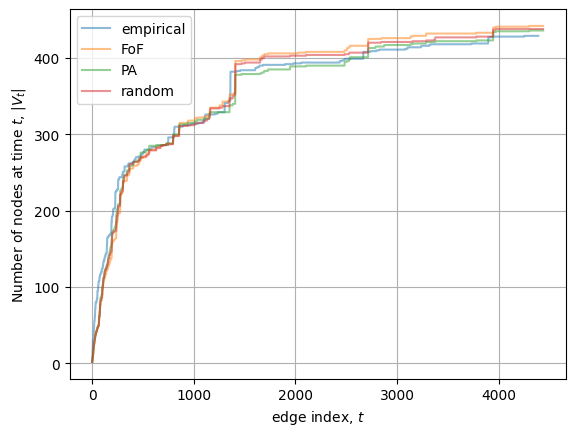

In [186]:
from metrics import evolution_nb_nodes, degrees_t, gini
%matplotlib inline
#H.cleanup(relabel = False, connected = True, multiedges= False)
freq = 1
for result in results:
    label = result['model']
    H = result['H']
    edges = [list(e) for e in H.edges.members()]

    N_t = evolution_nb_nodes(edges, freq)
    plt.plot(range( 0, len(N_t)*freq, freq), N_t, alpha = 0.5, label = label)


plt.xlabel("edge index, $t$")
plt.ylabel("Number of nodes at time $t$, $|V_t|$")
plt.grid()
plt.legend()
#plt.xscale('log')
plt.savefig(f'../out/Figures/N_t_{dataset}.pdf')


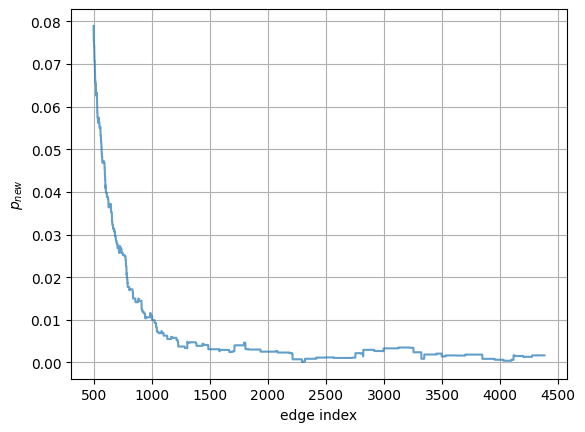

In [162]:
window_size = 500  # Adjust the window size as needed
P_new_smoothed = pd.Series(P_new).rolling(window=window_size).mean()

plt.plot(range(len(P_new_smoothed)), P_new_smoothed, alpha=0.7)
#plt.plot(range(len(P_new)), [np.mean(P_new)]*(len(P_new)))
plt.xlabel("edge index")
plt.ylabel("$p_{new}$")
plt.grid()
plt.savefig(f'../out/Figures/p_new_{dataset}.pdf')

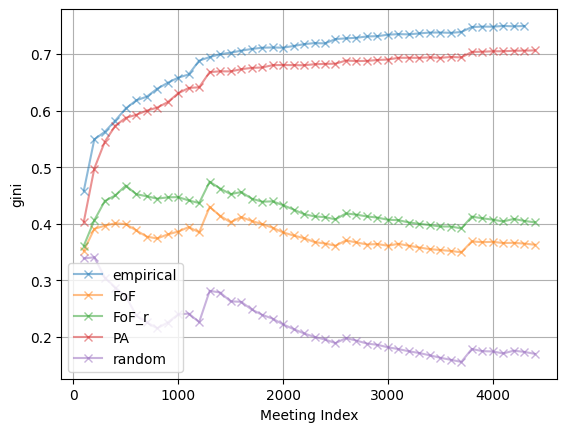

In [143]:
freq = 100
for result in results:
    label = result['model']
    H = result['H']
    edges = [list(e) for e in H.edges.members()]
    degrees = degrees_t(edges, freq)
    gini_list = [gini(element) for element in degrees]
    plt.plot(range(freq, len(gini_list)*freq,freq), gini_list[1:], label = label , alpha = 0.5, marker = 'x')



plt.ylabel('gini')
plt.xlabel('Meeting Index')
plt.legend()
plt.grid()
#plt.savefig('./out/Figures/gini_emp_rand.pdf')

In [ ]:
freq = 1000
for result in results:
    label = result['model']
    H = result['H']
    edges = [list(e) for e in H.edges.members()]
    degrees = degrees_t(edges, freq)

    mean_degree = [np.mean(element) for element in degrees]
    plt.plot(range(0, len(mean_degree)*freq,freq),mean_degree, label= label)


plt.legend()
plt.grid()
plt.ylabel('Mean degree')
plt.xlabel('Meeting Index')
#plt.savefig('./out/Figures/mean_emp_rand.pdf')

In [ ]:
freq = 1000
for result in results:
    label = result['model']
    H = result['H']
    edges = [list(e) for e in H.edges.members()]
    degrees = degrees_t(edges, freq)
    std_degree = [np.std(element) for element in degrees]
    plt.plot(range(0, len(std_degree)*freq,freq),std_degree, label= label)

plt.ylabel('Std Degree')
plt.xlabel('Meeting Index')
plt.grid()
plt.legend()
#plt.savefig('./out/Figures/std_degree_emp_rand.pdf')

In [172]:
import seaborn as sns

from itertools import combinations

nb_edges = 20000

start = 0
# Compute edge intersection size 
for result in results:
    label = result['model']
    H = result['H']
    edges = [list(e) for e in H.edges.members()]
    
    intersect = np.fromiter( tqdm((len(set(e) & set(f)) for e, f in combinations(edges[start :start + nb_edges], 2)), total=(nb_edges * (nb_edges - 1)) // 2) , dtype=int)
    result['intersection'] = intersect
    

100%|██████████| 199990000/199990000 [01:08<00:00, 2898647.26it/s]


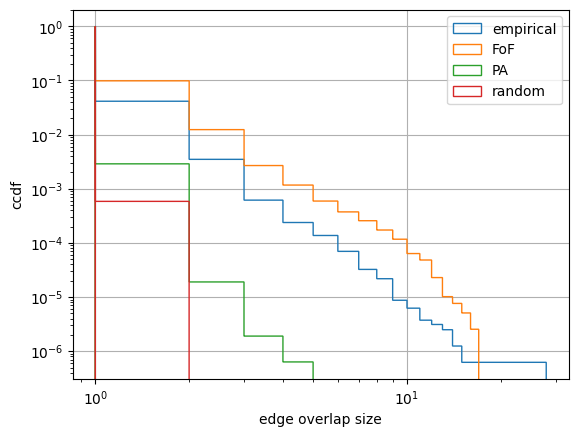

In [176]:
for result in results:
    label = result['model']
    n_bins = 4000
    x = np.asarray(result['intersection'])
    x = x[np.isfinite(x)]
    x = x[x > 0]
    if x.size == 0:
        continue
    bins = np.logspace(np.log10(x.min()), np.log10(x.max()), n_bins)
    plt.hist(result['intersection'], bins=bins, density=True, histtype="step", cumulative=-1,
            label = label)
            
    
plt.loglog()
plt.legend()
plt.grid()
plt.xlabel('edge overlap size')
plt.ylabel('ccdf')
plt.savefig(f'../out/Figures/intersection_{dataset}.pdf')

EdgeView((0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66, 67, 68, 69, 70, 71, 72, 73, 74, 75, 76, 77, 78, 79, 80, 81, 82, 83, 84, 85, 86, 87, 88, 89, 90, 91, 92, 93, 94, 95, 96, 97, 98, 99, 100, 101, 102, 103, 104, 105, 106, 107, 108, 109, 110, 111, 112, 113, 114, 115, 116, 117, 118, 119, 120, 121, 122, 123, 124, 125, 126, 127, 128, 129, 130, 131, 132, 133, 134, 135, 136, 137, 138, 139, 140, 141, 142, 143, 144, 145, 146, 147, 148, 149, 150, 151, 152, 153, 154, 155, 156, 157, 158, 159, 160, 161, 162, 163, 164, 165, 166, 167, 168, 169, 170, 171, 172, 173, 174, 175, 176, 177, 178, 179, 180, 181, 182, 183, 184, 185, 186, 187, 188, 189, 190, 191, 192, 193, 194, 195, 196, 197, 198, 199, 200, 201, 202, 203, 204, 205, 206, 207, 208, 209, 210, 211, 212, 213, 214, 215, 216, 217, 218, 219, 

In [30]:
from metrics import clustering_metrics
for result in results:
    label = result['model']
    H = result['H']
    edges = H.edges.members().copy()
    H_relabeled = xgi.Hypergraph()
    for e in edges:
        H_relabeled.add_edge(e, idx = f'e_{H_relabeled.num_edges}')
    print(label, clustering_metrics(H_relabeled))

empirical {'modularity': np.float64(0.6777148488050975), 'nb_clusters': np.int64(29)}
FoF {'modularity': np.float64(0.9265068398248842), 'nb_clusters': np.int64(73)}
PA {'modularity': np.float64(0.5005425907962588), 'nb_clusters': np.int64(61)}
random {'modularity': np.float64(0.5076561738398754), 'nb_clusters': np.int64(58)}


### Evolution number of clusters

In [67]:
from generator import triadic_closure, polyadic_closure_2
n = 10_000
#M = {2:10}
M = {2: 1, 3: 1, 4: 1}
n0 = 10
p = 0.99
seed = 1
H = polyadic_closure_2(n,M,p, n0 = n0,seed = seed)
H.cleanup(relabel = False, connected = True, multiedges= True)

In [ ]:
from metrics import nb_clusters

edges = list(H.edges.members())
freq = 3000

H_t = xgi.Hypergraph()             
nb_clusters_t = []
nb_edges = []
for start in range(0, len(edges), freq):
    batch = edges[start:start+freq]
    new_edges = {f'e_{eid}': nodes for eid, nodes in zip(range(H_t.num_edges, H_t.num_edges + len(batch)), batch )}
    H_t.add_edges_from(new_edges)
    nb_clusters_t.append(nb_clusters(H_t, random_state=0))  
    nb_edges.append(H_t.num_edges)


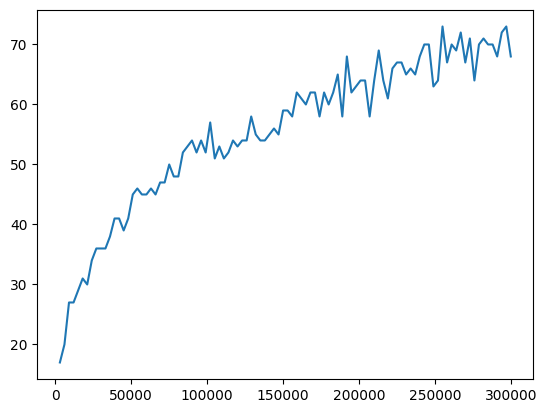

In [53]:
plt.plot(nb_edges, nb_clusters_t)

## Agregated Statistics

### Analytical solutions

In [6]:
# Analytical calculations
def fac(n):
    value = 1
    for i in range(2, n+1):
        value = value * i
    return value

def C(n, k, p):
    return fac(n)/(fac(k) * (fac(n-k))) * pow(p, k) * pow(1-p, n-k)

def p_card_e(p_n, p_r, d_m):
    d_m = int(d_m)
    X = []
    Y = []
    p = p_r + (1-p_r)*p_n
    for d in range(2, d_m+1):
        X.append(d)
        Y.append(C(d_m-1, d-1, p))
    Y = np.array(Y)/sum(Y)

    return {d: p_d for d, p_d in zip(X,Y)}

def avg_degree_an(N,M,p_r, p_n, d_m ):
    proba = p_card_e(p_n, p_r, d_m)
    return (1/N)*M*sum([d*p_d for d,p_d in proba.items()])


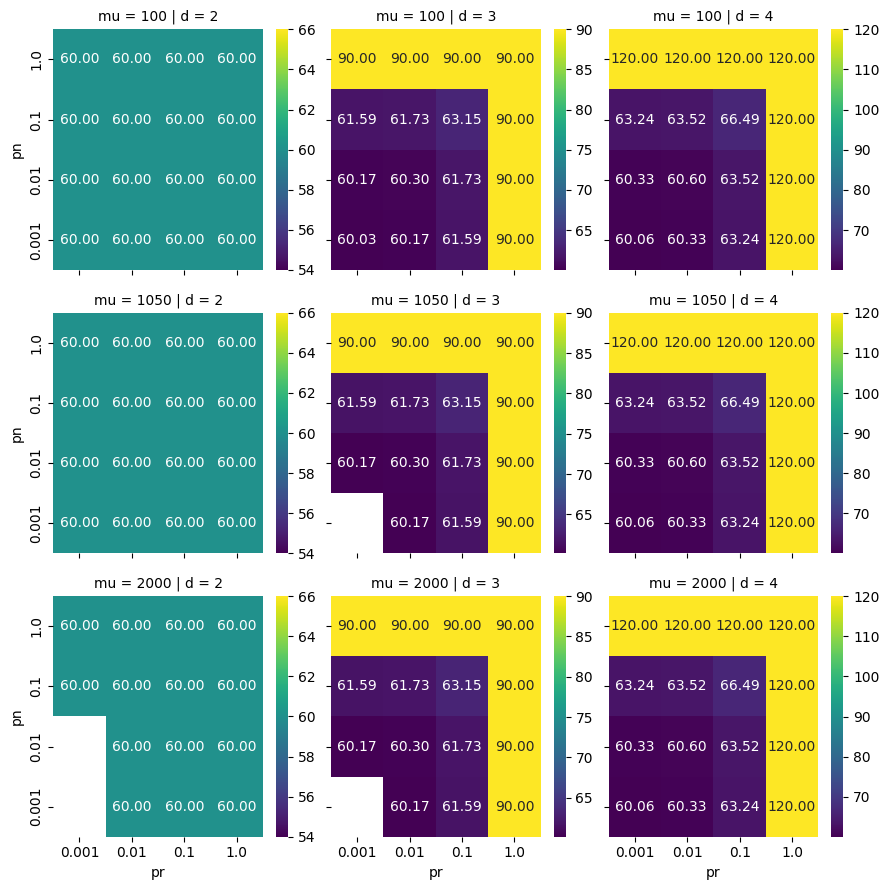

In [7]:
# Plot average degree
df['avg_degree_an'] = df.apply( lambda row: avg_degree_an(row['N'], row['M'], row['pr'], row['pn'], row['d']),
    axis=1)
feature = 'avg_degree_an'
g = sns.FacetGrid(df, row='mu', col='d')
g.map_dataframe(heatmap, data=df, feature=feature, cbar=True, cmap="viridis", annot=True, fmt=".2f")

plt.tight_layout()
plt.show()

## Temporal dynamics

### Load one simulation

In [35]:
def param_to_filename(param_dict):
    def fmt(val):
        return f"{val:.3f}" if isinstance(val, float) else str(val)
    return "_".join(f"{key}-{fmt(val)}" for key, val in param_dict.items())

N = 1_000
M = 30_000
mu = 1050
p_r = 0.001
p_n = 0.1
d = 3


param_dict = {"N": N, "M": M, "mu": mu, "pr": p_r, "pn": p_n, 'd': d}
filename = f'./out/temporal_H/{param_to_filename(param_dict)}.joblib'
H = joblib.load(filename)['hypergraph']

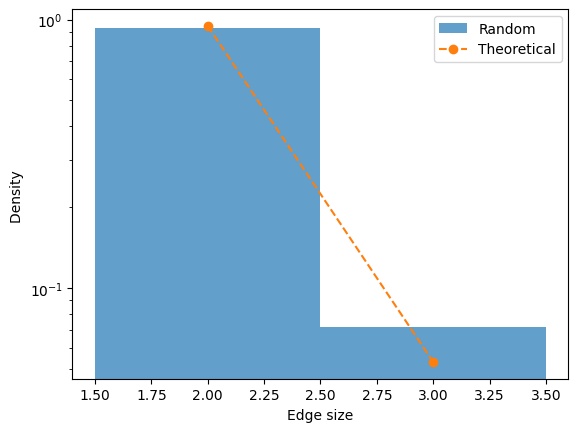

In [37]:
edge_size = [H.edges.size()[e] for e in H.edges]
#edge_size = (EC.meetings['TR ID'] + EC.meetings['EC member']).apply(len)

bins = range(2, max(edge_size)+2)
plt.hist(edge_size, bins=bins, density=True, log= True, align='left', label="Random", alpha = 0.7)


def fac(n):
    value = 1
    for i in range(2, n+1):
        value = value * i
    return value

def C(n, k, p):
    return fac(n)/(fac(k) * (fac(n-k))) * pow(p, k) * pow(1-p, n-k)

X = []
Y = []
for K in range(2, d+1):
    X.append(K)
    p = p_r + (1-p_r)*p_n
    Y.append(C(d-1, K-1, p))

Y = np.array(Y)/sum(Y)
plt.plot(X, Y, marker='o', linestyle='--', label="Theoretical")
plt.xlabel("Edge size")
plt.ylabel("Density ")
#plt.ylim(10**-6,1)
plt.legend()

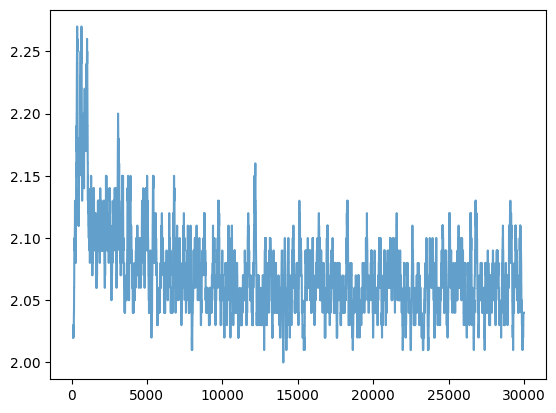

In [38]:
edge_size_rol = pd.Series(edge_size).rolling(window=100).mean()
plt.plot(range(len(edge_size_rol)), edge_size_rol, alpha=0.7)


69.9653735786496

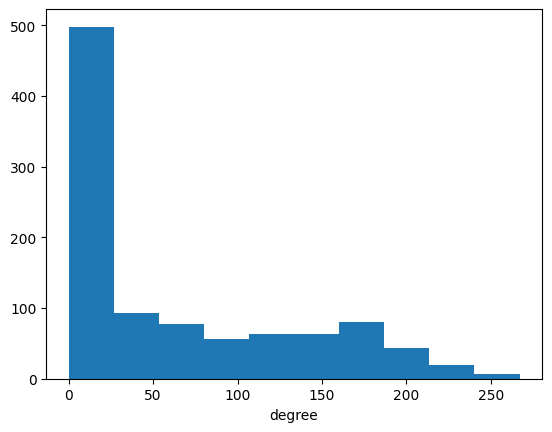

In [39]:
plt.hist([H.nodes.degree[i] for i in H.nodes])
plt.xlabel('degree')
np.std([H.nodes.degree[i] for i in H.nodes])

In [84]:
# Track evolution of H features
neighborhoord_size = []
size_largest_component = []
size_snd_largest_component = []
mod = []

# Set seed
seed = 10
np.random.seed(seed)
random.seed(seed)
# Set parameters for simulation
N = 1_000
M = 3_000
mu = 1050
p_r = 0.001
p_n = 0.1
d = 3
# Set param for tqdm bar 
param_dict = {"N": N, "M": M, "mu": mu, "pr": p_r, "pn": p_n, 'd': d}
desc_str = f"N={N}, M={M}, μ={mu:.3f}, pr={p_r:.3f}, pn={p_n:.3f}, d={d}"
pbar = tqdm(total=M, desc=desc_str, dynamic_ncols=True)

# Initialize H
H_t = xgi.Hypergraph() # temporal network
H_t.add_nodes_from(list(range(N)))
H = H_t.copy() # Aggregated network
t = 0 # time index

while H.num_edges < M:
    # Choose a node randomly
    e = set([np.random.choice(H_t.nodes)]) 
    for _ in range(d-1):
        #Get 1rst degree neighbors of nodes in e
        neighborhoods_1 = [H_t.nodes.neighbors(i) for i in e] 
        # N_e = union of N_i
        N_e_1 = set().union(*neighborhoods_1) 
        # Get 2nd degree neighbors of nodes
        neighborhoods_2 = [H_t.nodes.neighbors(i) for i in N_e_1] 
        # N_e = union of N_i
        N_e_2 = set().union(*neighborhoods_2) 
        # N_e 
        N_e = N_e_1 | N_e_2
        p = random.random()
        if N_e - e:
            # Random encounter
            if p < p_r:
                node = np.random.choice(list(set(H_t.nodes ) - e ))
                e.add(node)            
            # Meet a friend of friend
            else:
                if p < p_n :
                    node = np.random.choice(list(N_e - e))
                    e.add(node)    
        else:
            # Random encounter
            if p < p_r:
                node = np.random.choice(list(set(H_t.nodes ) -e )) 
                e.add(node)    
    # Add e to the set of edges 
    if len(e)>1 and e not in H_t.edges.members():
        H_t.add_edge(e, idx = f'e_{t}')
        H.add_edge(e, idx = f'e_{t}')
        t +=1
        pbar.update(1)
    
        if H.num_edges %100 ==0 and H.num_edges > 1:
            # Compute size of connected components of H_t
            components = list(xgi.connected_components(H_t))
            components = sorted(components, key = len, reverse = True)
            size_largest_component.append(len(components[0]))
            if len(components)>1:
                size_snd_largest_component.append(len(components[1]))
            else:
                size_snd_largest_component.append(0)
            # Compute modularity of H_t
            mod.append(modularity(H_t))
        
    # Remove a random edge
    if H_t.num_edges >= mu:
        e_remove = np.random.choice(H_t.edges)
        H_t.remove_edge(e_remove)
    

    # Evolution H features
    neighborhoord_size.append(len(N_e))


pbar.close()


N=1000, M=3000, μ=1050.000, pr=0.001, pn=0.100, d=3: 100%|██████████| 3000/3000 [00:13<00:00, 216.70it/s]


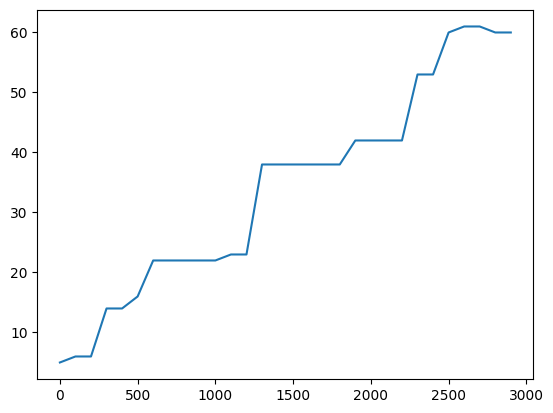

In [86]:
plt.plot(range(0, len(size_largest_component)*100, 100), size_largest_component)
#plt.plot(range(0, len(size_largest_component)*100, 100), size_snd_largest_component)

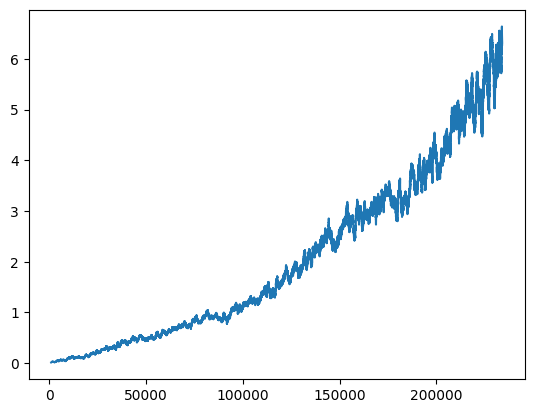

In [87]:
neighborhoord_size_avg = pd.Series(neighborhoord_size).rolling(window=1000).mean()
plt.plot(range(len(neighborhoord_size_avg)), neighborhoord_size_avg)

In [24]:
node_labels, node_clusters, edge_clusters = clustering(H)
G = xgi_2_sknetwork(H)
biadjacency_matrix = G.biadjacency
print('Moduliarty = ', get_modularity(biadjacency_matrix, node_clusters, edge_clusters))
print('nb clusters = ' , max(node_clusters))

Moduliarty =  0.8458204800519143
nb clusters =  76


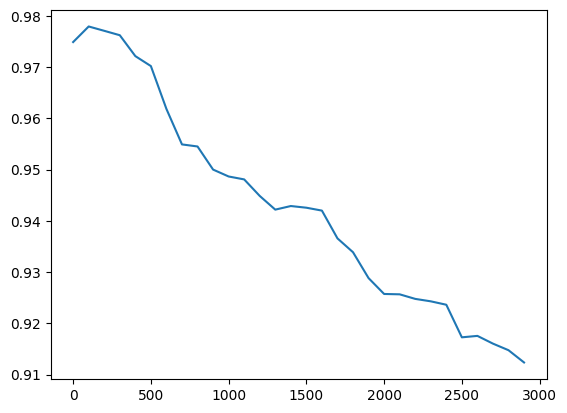

In [88]:
plt.plot(range(0,len(mod)*100,100), mod)

# Evolution of centralities

In [ ]:

def sub_hypergraph(meetings, start, end):

    df = meetings[(meetings['Date'] > start) & (meetings['Date'] < end)].copy()
    hyperedges =  df['TR ID']
    H = xgi.Hypergraph( dict( hyperedges.apply(lambda x : list(x))))
    return H

def cent_H_t(freq: str, time_slice: bool):

    EC.meetings['Date'] = pd.to_datetime(EC.meetings['Date'])

    min_date = EC.meetings['Date'].min()
    max_date = EC.meetings['Date'].max()

    cent = pd.DataFrame(index =EC.entities.index)
    cent['TR Name'] = EC.entities['TR Name']
    date_ranges = pd.date_range(min_date, max_date, freq= freq)

    for i in range (len(date_ranges)-1):
        if time_slice:
            # Generate a Hypergraph with interactions accouring between t and t + freq
            H = sub_hypergraph(EC.meetings, date_ranges[i],date_ranges[i+1])
        else:
            # Generate a Hypergraph with interactions accouring between 0 and t 
            H = sub_hypergraph(EC.meetings, date_ranges[0],date_ranges[i+1])
        # Compute centratily 
        centrality = pd.DataFrame({date_ranges[i] : dict(H.degree()).values()}, index = dict(H.degree()).keys()) 
        # Add the result to dataframe with index  = entities
        cent = pd.concat([cent, centrality], axis=1)

    return cent

def cent_H_t_meeting(freq: int, time_slice: bool):
    degrees = []
    for i in range(len(EC.meetings)//freq):
        if time_slice :
            hyperedges = EC.meetings['TR ID'].iloc[i*freq: (i+1)*freq]
        else:
            hyperedges = EC.meetings['TR ID'].iloc[: (i+1)*freq]
        degrees.append(list(Counter(hyperedges).values()))
    return degrees
#cent = cent_H_timestamp('9ME')

## Jaccard Similarity of degree rank
Compute jaccard similarity using the “ranked Jaccard”, a measure to compare rankings: From each top-k list we build a new list where each element, at position r of the top-k, is identically repeated k − r times. Then the Jaccard similarity is calculated between the expanded lists.

Text(0, 0.5, 'Jaccard similarity')

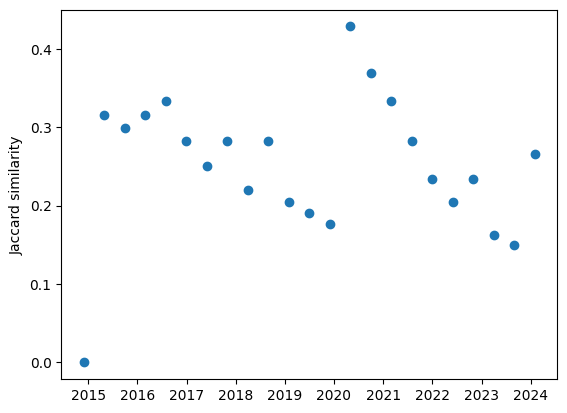

In [ ]:
k = 50
cent = cent_H_t('5ME', time_slice = True)

jaccard_set = []
for year in list(cent.columns):
    top_k = cent[year].sort_values(ascending = False).head(k).index
    
    jaccard_set.append(set(top_k))

    # jaccard_set_y = []
    # for i, entity in enumerate(top_k):
    #     jaccard_set_y += [entity for _ in range(len(top_k),i,-1)]
        
    # jaccard_set.append(set(jaccard_set_y))
    
jaccard_index = [len(jaccard_set[i] & jaccard_set[i+1]) /len(jaccard_set[i] | jaccard_set[i+1]) for i in range(len(jaccard_set) -1)]
plt.scatter(list(cent.columns)[1:], jaccard_index)
plt.ylabel('Jaccard similarity')

## Visualization

In [ ]:
X = EC.H.copy()
B = XGI_2_nxBipartite(X)


attr = dict(zip(EC.entities.index, EC.entities['Type']))
nx.set_node_attributes(B, attr,'Type')

attr = dict(zip(EC.entities.index, EC.entities['Category of registration']))
attr.update( dict(zip(EC.entities.index, EC.entities['Category of registration'])))
nx.set_node_attributes(B, attr,'Partition')

nx.write_gexf(B, "./out/H.gexf")

In [ ]:
X = EC.sub_hypergraph()
B = XGI_2_nxBipartite(X)


attr = dict(zip(EC.entities.index, EC.entities['Type']))
nx.set_node_attributes(B, attr,'Type')

attr = dict(zip(EC.entities.index, EC.entities['Category of registration']))
attr.update( dict(zip(EC.entities.index, EC.entities['Category of registration'])))
nx.set_node_attributes(B, attr,'Partition')

nx.write_gexf(B, "./out/H_orga.gexf")